In [1]:
import sys
import os
import numpy as np
import time
import MDAnalysis as mda
from MDAnalysis.analysis import align

import matplotlib.pyplot as plt

import utility

#from scipy.spatial.distance import pdist
from scipy.spatial.distance import cdist

from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA


/home/jonathan/anaconda3/envs/serpents/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
def tmd_query():
    segment_resis = [[77, 149], [192, 245], [298, 362], [988, 1034], [857, 889], [900, 942], [1094, 1154]]
    #print("color blue, " + " or ".join([f"resi {sr[0]}-{sr[1]}" for sr in segment_resis]))

    segment_resis_all = [i for sr in segment_resis for i in range(sr[0], sr[1]+1)]
    query = " or ".join([f"resid {sr}" for sr in segment_resis_all])

    # print_indices = frame.top.select(f"protein and name CA and ({query})")
    # print("+".join([str(i+1) for i in print_indices]))
    return f"protein and ({query})"

In [3]:
def load_frame(top_path, xtc_path=None, frame_index = -1):

    if xtc_path is None:
        u = mda.Universe(top_path)
    else:
        u = mda.Universe(top_path, xtc_path) #, topology_format='ITP'

    u.trajectory[frame_index]

    # create a new universe from that frame
    u_last = mda.Merge(u.atoms)

    # copy box, which for some reason merge does not do
    u_last.dimensions = u.dimensions

    return u_last

In [4]:
#these observables are all best calculated from a non-aligned trajectory since they depend on z
def get_waters_phosphates_boxvectors(u):

    # ============================
    # MEMBRANE PHOSPHATES
    # ============================

    phosphates = u.select_atoms("resname PC and name P31")

    if len(phosphates) == 0:
        raise ValueError("No phosphate atoms found. Check lipid resnames and phosphate atom name.")

    #print(phosphates.positions.shape)

    z_positions = phosphates.positions[:, 2]
    z_mean = np.mean(z_positions)

    # Separate into upper and lower leaflets
    upper_leaflet = phosphates[z_positions > z_mean]
    lower_leaflet = phosphates[z_positions <= z_mean]

    if len(upper_leaflet) == 0 or len(lower_leaflet) == 0:
        raise ValueError("Leaflet separation failed.")

    z_upper_avg = np.mean(upper_leaflet.positions[:, 2])
    z_lower_avg = np.mean(lower_leaflet.positions[:, 2])

    membrane_thickness = z_upper_avg-z_lower_avg

    # ============================
    # WATERS WITHIN MEMBRANE
    # ============================

    waters = u.select_atoms("resname TP3 and name O")

    water_z = waters.positions[:, 2]
    z_pad = 0

    inside_mask = (water_z > z_lower_avg-z_pad) & (water_z < z_upper_avg+z_pad)
    waters_inside = waters[inside_mask]

    return u.dimensions, membrane_thickness, waters_inside



In [5]:
def contacts_bin(group_1, group_2, cutoff=5.0, flat=False):

    sqdistances = cdist(group_1.positions, group_2.positions, 'sqeuclidean')
    # if cutoff == 3.3:
    #     print(np.sqrt(sqdistances))
    #     print(group_1.positions, group_2.positions)
    #identify contacts
    contacts = np.where(sqdistances < cutoff**2, 1, 0)

    #calculate whether each atom of group 1 contacts any atom of group 2
    if flat:
        contacts = np.where(np.sum(contacts, axis=1) > 0, 1, 0)

    return contacts

In [ ]:
#align trajectory and calculate aligned water positions and various contacts
def get_water_contacts(u, ref, water_sel):
    # print(u.atoms.positions)
    # print(water_sel.positions)

    #hbonds = hbonds_salt_bridge(u)

    t0 = time.time()
    align.AlignTraj(u, ref, select=f"{tmd_query()} and name CA", in_memory=False).run()
    t1 = time.time()
    print(f"align: {t1-t0}")

    # print(u.atoms.positions)
    # print(water_sel.positions)

    t0 = time.time()
    #protein, ligand, and lipid selections
    protein_sel = u.select_atoms(f"{tmd_query()} and not name H*")
    ligand_sel  = u.select_atoms(f"resname LJP and not name H*")
    lipid_sel   = u.select_atoms(f"(resname PA or resname OL) and not name H*")
    pyr_hb_donor = u.select_atoms(f"resname LJP and name N2")
    pyr_hb_acceptor = u.select_atoms(f"resname LJP and name N3")
    R933_hb_donor = u.select_atoms(f"resname ARG and resid 933 and name NE NH1 NH2")
    E873_hb_acceptor = u.select_atoms(f"resname GLU and resid 873 and name OE1 OE2")
    t1 = time.time()
    print(f"sele: {t1-t0}")

    if False:
        print(f"{len(protein_sel)} protein atoms")
        print(f"{len(ligand_sel)} ligand atoms")
        print(f"{len(lipid_sel)} lipid atoms")
        print(f"{len(water_sel)} water atoms")

    t0 = time.time()
    prot_lig = contacts_bin(protein_sel, ligand_sel, cutoff=5.0, flat=False)
    prot_lip = contacts_bin(protein_sel, lipid_sel, cutoff=5.0, flat=True)
    prot_wat = contacts_bin(protein_sel, water_sel, cutoff=5.0, flat=True)
    lig_lip = contacts_bin(ligand_sel, lipid_sel, cutoff=5.0, flat=True)
    lig_wat = contacts_bin(ligand_sel, water_sel, cutoff=5.0, flat=True)

    hb_ljp_donor = contacts_bin(pyr_hb_donor, E873_hb_acceptor, cutoff=3.3, flat=True)[0]
    hb_ljp_acceptor = contacts_bin(pyr_hb_acceptor, R933_hb_donor, cutoff=3.3, flat=True)[0]

    t1 = time.time()
    print(f"dists: {t1-t0}")

    return protein_sel, ligand_sel, water_sel.positions, ligand_sel.positions, prot_lig, prot_lip, prot_wat, lig_lip, lig_wat, hb_ljp_donor, hb_ljp_acceptor

In [7]:
def main(ref_path, gro_path, xtc_path, frame=-1):
    t0 = time.time()
    u = load_frame(gro_path, xtc_path, frame)
    t1 = time.time()
    print(t1-t0)

    boxdims, thickness, waters_inside = get_waters_phosphates_boxvectors(u)
    t2 = time.time()
    print(t2-t1)

    ref = mda.Universe(ref_path)
    t3 = time.time()
    print(t3-t2)

    protein_sel, ligand_sel, water_pos, lig_pos, prot_lig, prot_lip, prot_wat, lig_lip, lig_wat, hb_ljp_donor, hb_ljp_acceptor = get_water_contacts(u, ref, waters_inside)
    t4 = time.time()
    print(t4-t3)


    return protein_sel, ligand_sel, water_pos, lig_pos, prot_lig, prot_lip, prot_wat, lig_lip, lig_wat, hb_ljp_donor, hb_ljp_acceptor, boxdims, thickness

In [8]:
ref_path = "/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.gro"
gro_path = "/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.gro"
#top_path = "/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/gromacs_config/topol.top" # <-- too slow

xtc_path = "/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/001913-000187-trj-pbcmol-centered-tmd-rot-s10.xtc"
#"/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/2.5A-20A/001913-000187-traj_comp.xtc"

protein_sel, ligand_sel, water_pos, lig_pos, prot_lig, prot_lip, prot_wat, lig_lip, lig_wat, hb_ljp_donor, hb_ljp_acceptor, boxdims, thickness = main(ref_path, gro_path, xtc_path)

0.740314245223999
0.0045795440673828125
0.8482718467712402
align: 0.31710171699523926
sele: 0.19656848907470703
dists: 0.13437390327453613
0.6484024524688721


In [ ]:
#hb_acc = []
hb = []
for frame in range(0,573,5):
    print(frame)
    protein_sel, ligand_sel, water_pos, lig_pos, prot_lig, prot_lip, prot_wat, lig_lip, lig_wat, hb_ljp_donor, hb_ljp_acceptor, boxdims, thickness = main(ref_path, gro_path, xtc_path, frame)
    # if hb_ljp_acceptor[0] == 1 or hb_ljp_donor[0] == 1:
    #     print("-------------------------------------------------")
    #     print(hb_ljp_acceptor)
    #     print(hb_ljp_donor)
    hb_acc.append(hb_ljp_acceptor[0])
    hb_don.append(hb_ljp_donor[0])

plt.plot(hb_acc)
plt.plot(hb_don)


0
0.7485623359680176
0.004510164260864258
0.8646194934844971
align: 0.30913662910461426
sele: 0.21179413795471191
dists: 0.1382617950439453
0.6594491004943848


IndexError: invalid index to scalar variable.

In [50]:
u = mda.Universe(gro_path, xtc_path)
len(u.trajectory)

573

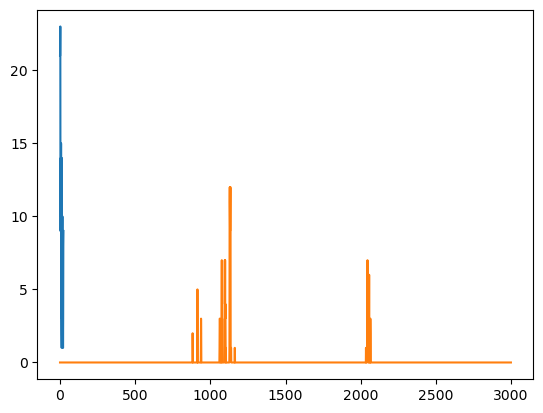

In [64]:
plt.plot(np.sum(prot_lig, axis=0))
plt.plot(np.sum(prot_lig, axis=1))

In [ ]:
utility.write_bfactors_by_residue_match("/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.pdb", protein_sel, prot_wat,
                                "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1-visualization/input_prot_water.pdb")
utility.write_bfactors_by_residue_match("/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.pdb", ligand_sel, lig_wat,
                                "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1-visualization/input_lig_water.pdb")
utility.write_bfactors_by_residue_match("/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.pdb", protein_sel, prot_lip,
                                "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1-visualization/input_prot_lipid.pdb")
utility.write_bfactors_by_residue_match("/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.pdb", ligand_sel, lig_lip,
                                "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1-visualization/input_lig_lipid.pdb")

In [65]:
utility.write_bfactors_by_residue_match("/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.pdb", ligand_sel, np.where(np.sum(prot_lig, axis=0), 1, 0),
                                "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1-visualization/input_prot_lig.pdb")
utility.write_bfactors_by_residue_match("/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.pdb", protein_sel, np.where(np.sum(prot_lig, axis=1), 1, 0),
                                "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1-visualization/input_lig_prot.pdb")

/home/jonathan/anaconda3/envs/serpents/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:346: UserWarning: Unknown element P3 found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/home/jonathan/anaconda3/envs/serpents/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Unknown entry 1 encountered in formal charge field. This likely indicates that the PDB file is not fully standard compliant. The formalcharges attribute will not be populated.
  warnings.warn(wmsg)
/home/jonathan/anaconda3/envs/serpents/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"
/home/jonathan/anaconda3/envs/serpents/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:120

In [ ]:

# # t0 = time.time()
# u = load_frame(gro_path, xtc_path)
# # t1 = time.time()
# # print(t1-t0)

# boxdims, thickness, waters_inside = get_waters_phosphates_boxvectors(u)

# # t0 = time.time()
# ref = mda.Universe(gro_path)
# # t1 = time.time()
# # print(t1-t0)

# water_pos, prot_lig, prot_lip, prot_wat, lig_lip, lig_wat = get_water_contacts(u, ref, waters_inside)

# print(prot_lig.shape)
# print(prot_lip.shape)
# print(prot_wat.shape)
# print(lig_lip.shape)
# print(lig_wat.shape)

In [ ]:
# def load_align():
#     # ============================
#     # LOAD TRAJECTORY
#     # ============================

#     #ref_frame_path_x01 = '/media/X01Raid01/Data_Backup/home/csheen/cftr-project/wstp_cftr_1_degrabo/bstates/input/min.gro'
#     ref_frame_path = '/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.gro'

#     ref_frame = mda.Universe(ref_frame_path)

#     gro_file = "/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.gro"
#     xtc_file = "/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/001913-000187-trj-pbcmol-centered-tmd-rot-s10.xtc"

#     # Frame index to analyze
#     frame_index = -1

#     u_aligned = mda.Universe(gro_file, xtc_file)
#     align.AlignTraj(u_aligned, ref_frame, select=f"{tmd_query()} and name CA", in_memory=True)
#     u_aligned.trajectory[frame_index]
#     print(u_aligned.trajectory.frame)

#     u_unaligned = mda.Universe(gro_file, xtc_file)
#     u_unaligned.trajectory[frame_index]
#     print(u_unaligned.trajectory.frame)

#     return u_aligned, u_unaligned
    
# u_a, u_u = load_align()

In [ ]:
# u_a.select_atoms("protein").positions

In [ ]:
# u_u.select_atoms("protein").positions

In [ ]:
# def load_align_frame(ref_path, gro_path, xtc_path, query, frame_index = -1):

#     ref = load_frame(ref_path, frame_index=frame_index)
#     frame = load_frame(gro_path, xtc_path, frame_index=frame_index)
#     print(ref.atoms.positions)

#     print(frame.atoms.positions)
#     align.AlignTraj(frame, ref, select=query, in_memory=True).run()
#     print(frame.atoms.positions)

#     return frame

# f = load_align_frame(top_path,#this requires loading with topol.top which is absurdly slow


In [ ]:
#will have to write a different version for lipidated drug
def hbonds_salt_bridge(u):

    d_a_cutoff=3.3

    h1 = HBA(universe=u, hydrogens_sel=f"resname LJP and name H14",
            acceptors_sel="resname GLU and resid 873 and name OE1 OE2", update_selections=False, d_a_cutoff=d_a_cutoff)
    h1.run()

    h2 = HBA(universe=u, hydrogens_sel="resname ARG and resid 933 and name HE HH11 HH12 HH21 HH22", 
            acceptors_sel=f"resname LJP and name N3", update_selections=False, d_a_cutoff=d_a_cutoff)
    h2.run()

    print(h1.results)
    print(h2.results) top_path, xtc_path, query, frame_index = -1)